In [2]:
import pandas as pd

### plan na ten notebook

* puscic lasso na kazdej kategorii osobno ale tez wspolnie

# Checking the distribution of the components grouped by category

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
calculated_comp_WS = pd.read_csv('calculated_components\calculated_components_WS.csv')
# calculated_comp_WS.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_BA = pd.read_csv('calculated_components\calculated_components_BA.csv')

# calculated_comp_BA.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_ER = pd.read_csv('calculated_components\calculated_components_ER.csv')

# calculated_comp_ER.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_RGG = pd.read_csv('calculated_components\calculated_components_RGG.csv')

calculated_comp_all = pd.read_csv('calculated_components\calculated_components_all.csv')


# calculated_comp_all = pd.concat([calculated_comp_WS, calculated_comp_BA, calculated_comp_ER, calculated_comp_RGG], axis=0)
calculated_comp_all.head()

,score,node_distribution_unreversed,node_distribution,node_distribution_raw,distance_to_borderlines_unreversed,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution_unreversed,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,6,14.829592,23.876561,17.780065,24.0,55.398,20.337,2.152635,3.592560,18.886689,50.993856,33.782377,0,0,4.595035,1.818732,0.923854,WS
1,2,9.414349,125.106129,33.453750,24.0,48.836,22.544,2.214927,3.371768,11.224078,6248.677875,184.254477,4,2,4.291184,1.857574,0.994254,WS
2,3,6.608169,134.195630,40.020260,24.0,20.004,17.203,1.848901,3.281957,6.695052,8240.742150,206.081081,25,5,2.975655,2.057628,0.994107,WS
3,4,7.465641,140.190159,39.631039,24.0,12.336,14.229,2.198073,3.399477,7.175088,1227.674901,129.139425,16,4,3.338765,1.824807,0.983865,WS
4,5,10.232899,53.373121,26.006497,24.0,32.118,18.622,3.359785,4.151853,11.855137,357.605692,69.221441,4,2,4.698183,1.976676,0.983869,WS


In [18]:
def plot_component_distribution(calculated_comp_all, component_name):
    palette_dict = dict(zip(calculated_comp_all['category'].unique(), ['#C0000D','#17195C','#91A3B5','#0F0F29','#510C2D','#C0000D']))
    fig, axes = plt.subplots(1, 4, figsize=(16, 4) )
    axes = axes.flatten()
    unique_algos = calculated_comp_all['category'].unique()

    # Iterate over each subplot and unique bestnum_algo
    for ax, algo in zip(axes, unique_algos):
        # Filter data for the current bestnum_algo
        subset = calculated_comp_all[calculated_comp_all['category'] == algo]
        sns.histplot(data=subset, x=component_name, bins=10, kde=False, ax=ax, color=palette_dict[algo])
        # Customize the subplot
        ax.set_title(f'{algo}')
        ax.set_xlabel(component_name)
        # ax.set_ylabel('Abs Diff')

    plt.tight_layout()
    fig.suptitle(component_name)
    # plt.title('Assortativity distribution grouped by sizes')
    plt.show()

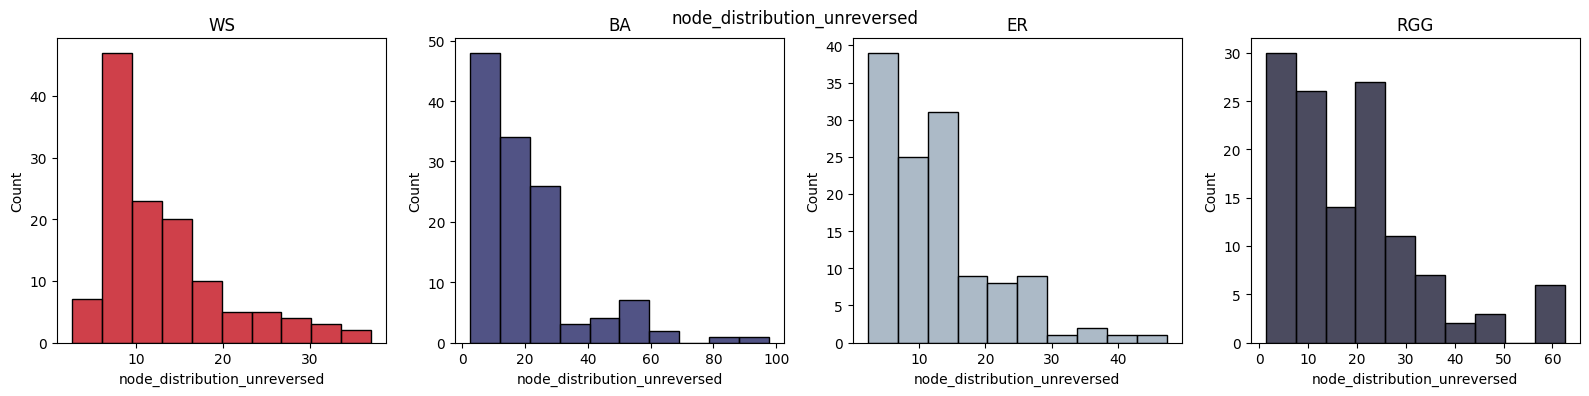

In [19]:
plot_component_distribution(calculated_comp_all, 'node_distribution_unreversed')

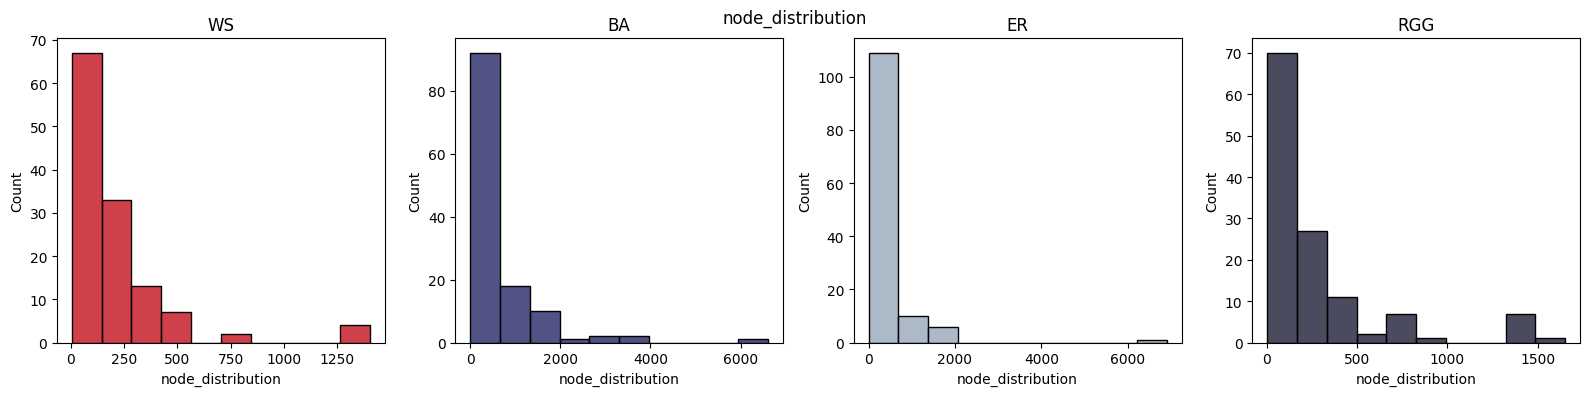

In [20]:
plot_component_distribution(calculated_comp_all, 'node_distribution')

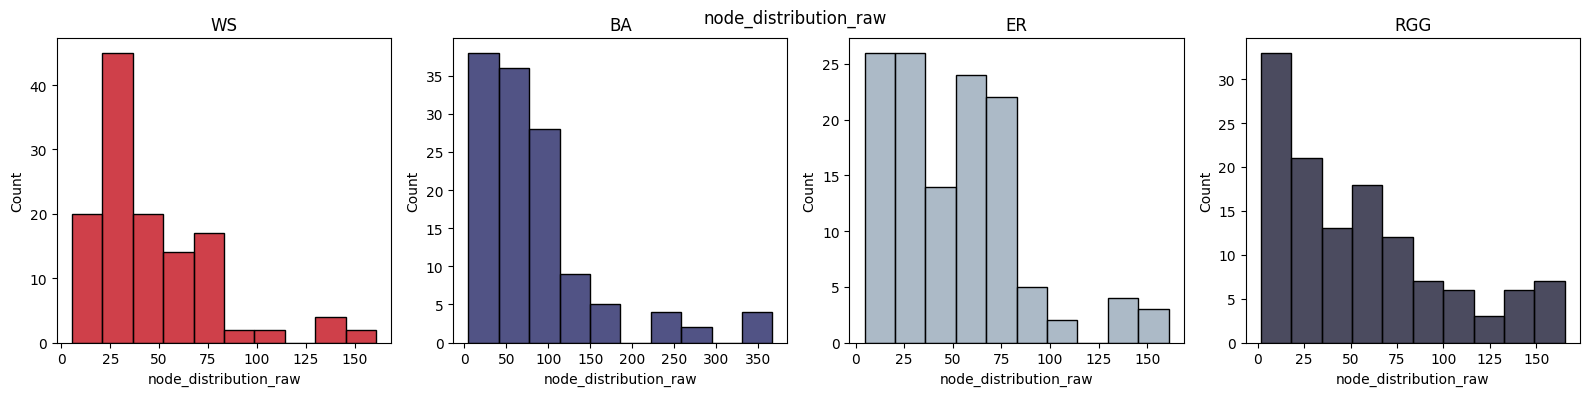

In [21]:
plot_component_distribution(calculated_comp_all, 'node_distribution_raw')

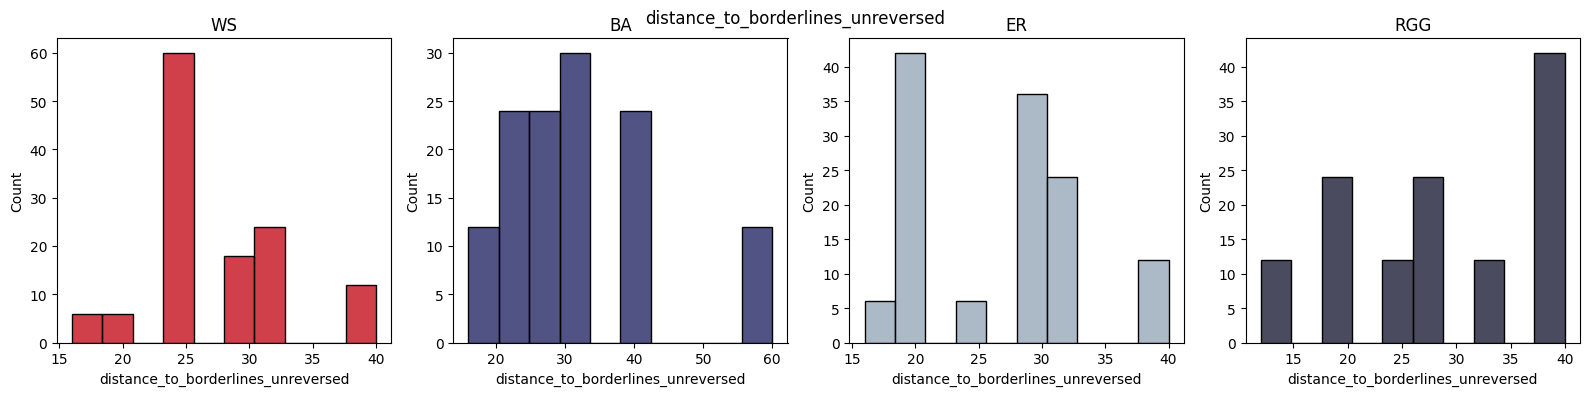

In [22]:
#wydaje mi sie ze to jest totlanie bez sensu xd 
plot_component_distribution(calculated_comp_all, 'distance_to_borderlines_unreversed')

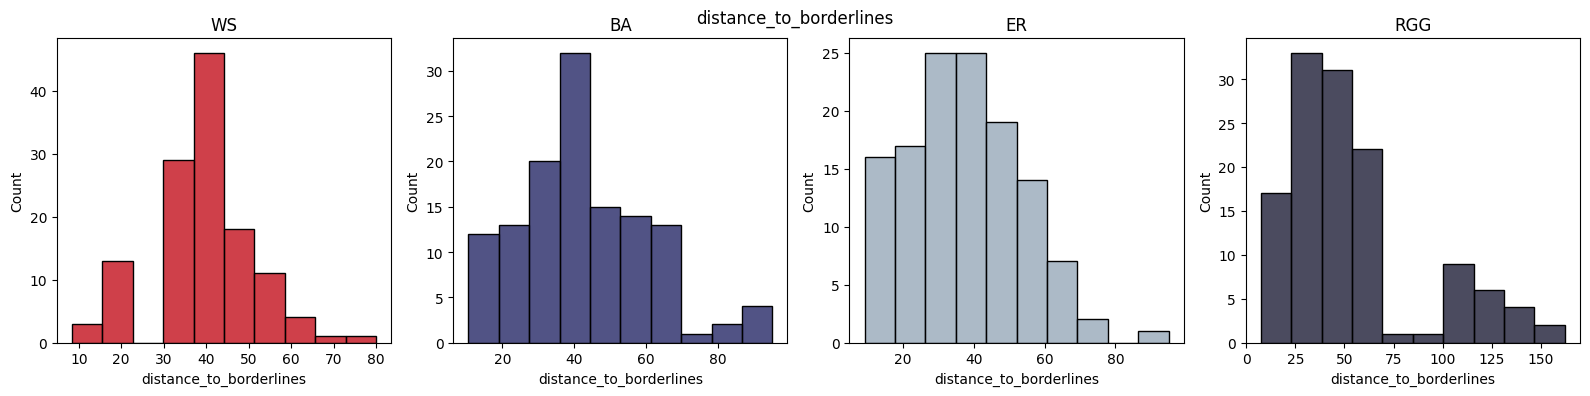

In [23]:
plot_component_distribution(calculated_comp_all, 'distance_to_borderlines')

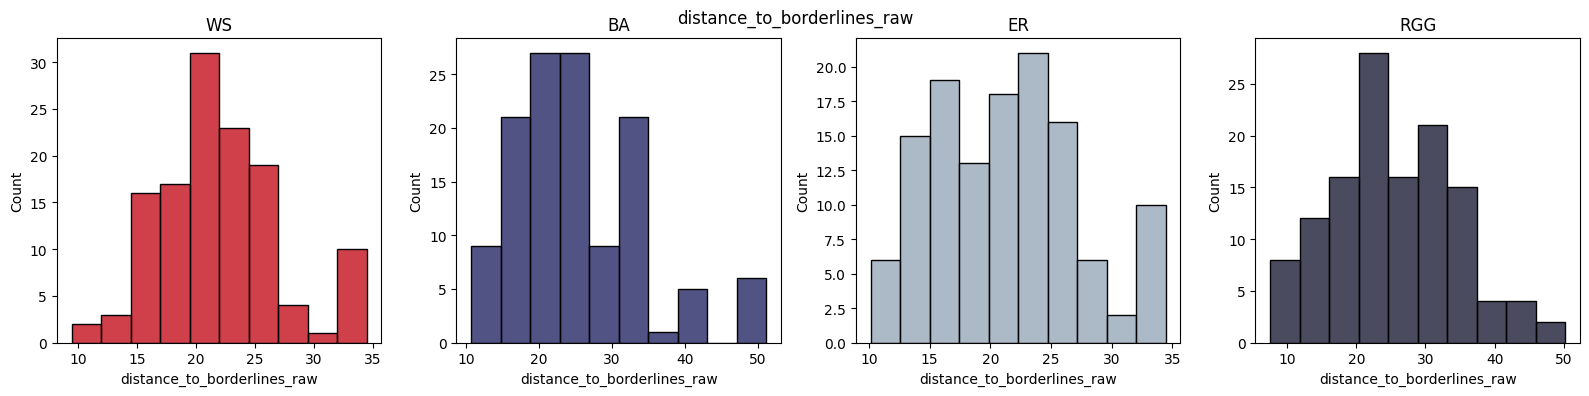

In [24]:
plot_component_distribution(calculated_comp_all, 'distance_to_borderlines_raw')

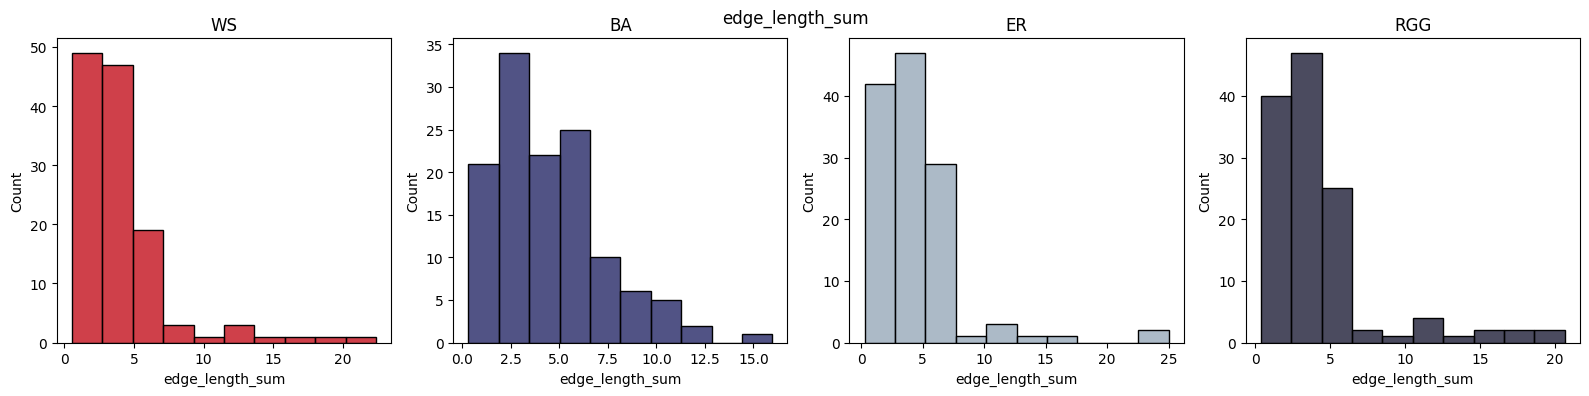

In [25]:
plot_component_distribution(calculated_comp_all, 'edge_length_sum')

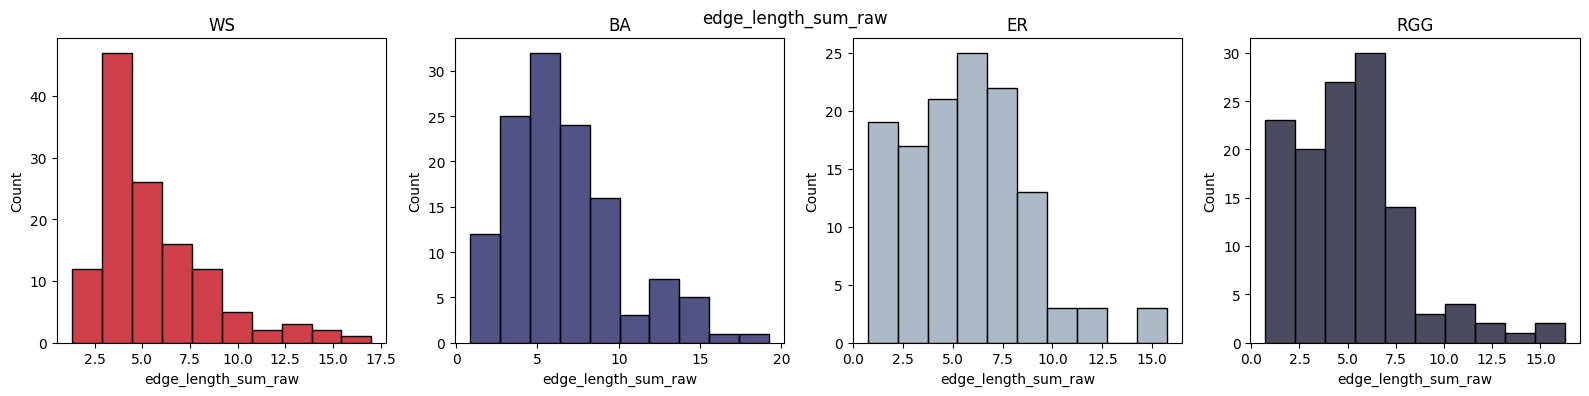

In [26]:
plot_component_distribution(calculated_comp_all, 'edge_length_sum_raw')

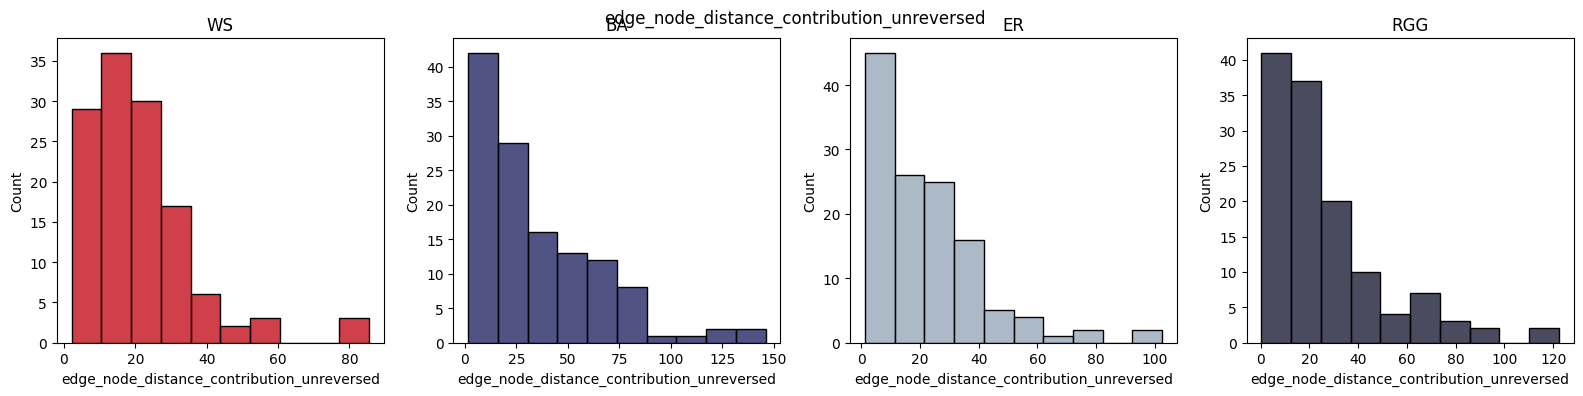

In [27]:
plot_component_distribution(calculated_comp_all, 'edge_node_distance_contribution_unreversed')

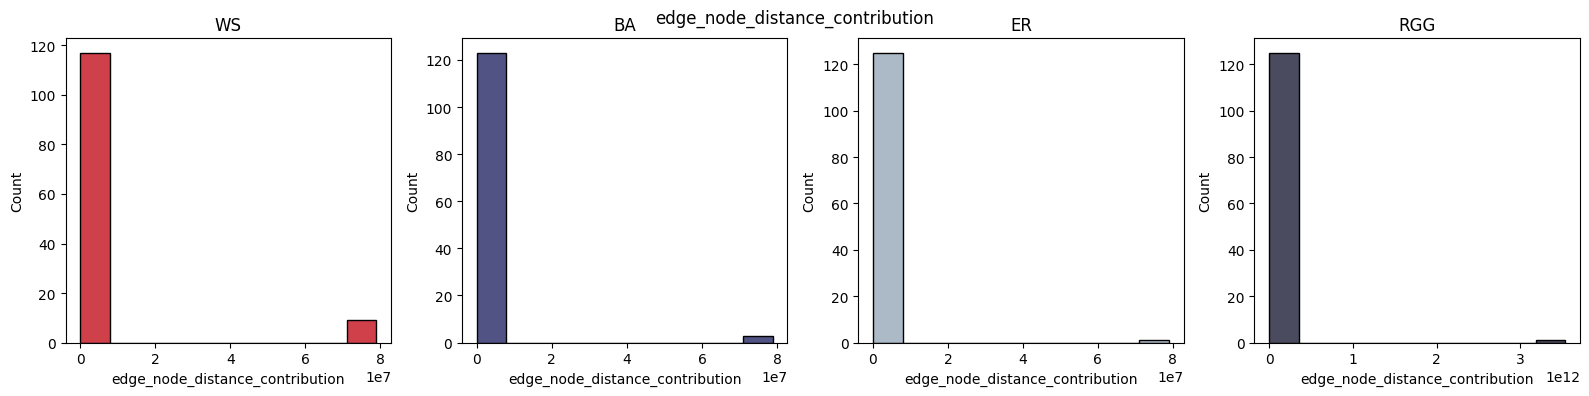

In [28]:
plot_component_distribution(calculated_comp_all, 'edge_node_distance_contribution')

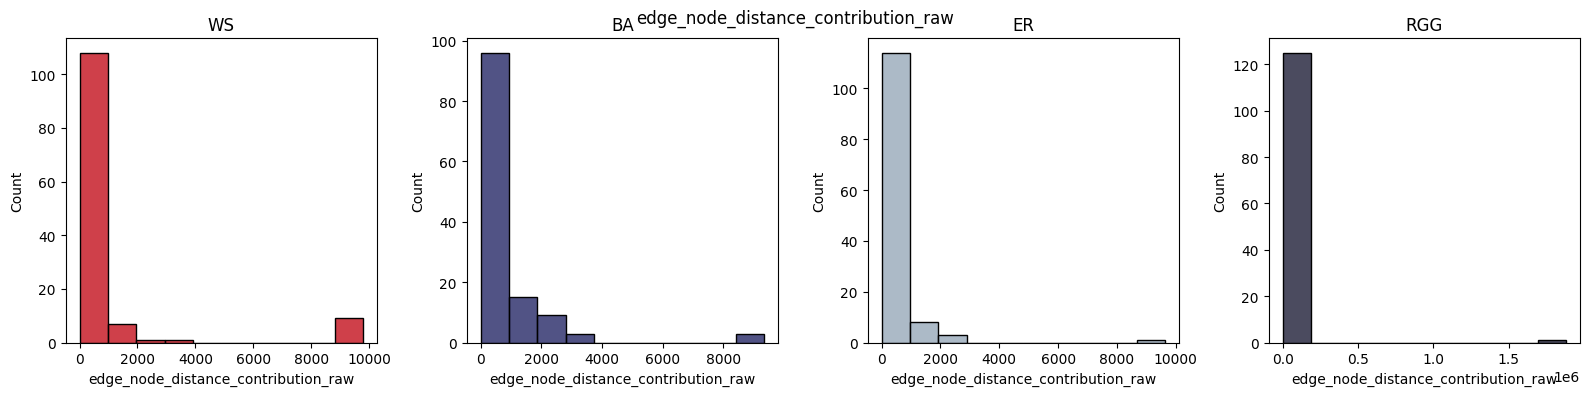

In [29]:
plot_component_distribution(calculated_comp_all, 'edge_node_distance_contribution_raw')

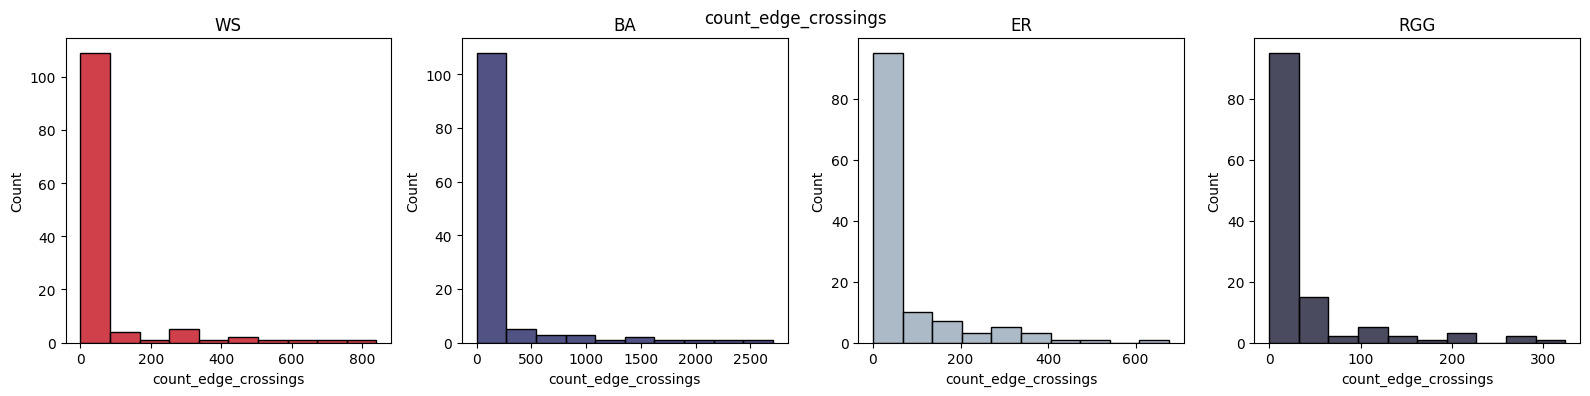

In [30]:
plot_component_distribution(calculated_comp_all, 'count_edge_crossings')

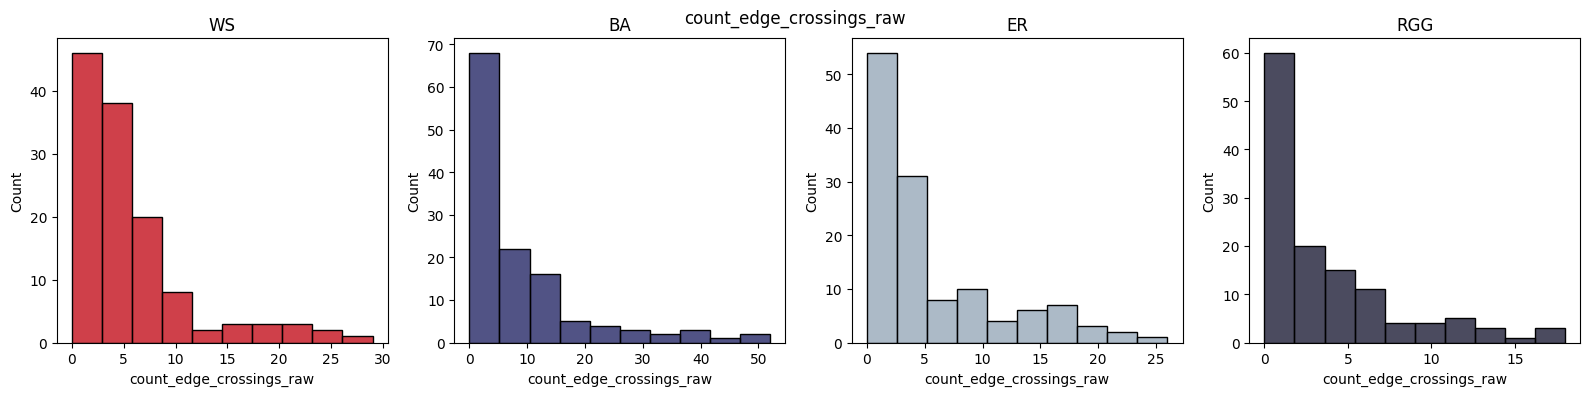

In [31]:
plot_component_distribution(calculated_comp_all, 'count_edge_crossings_raw')

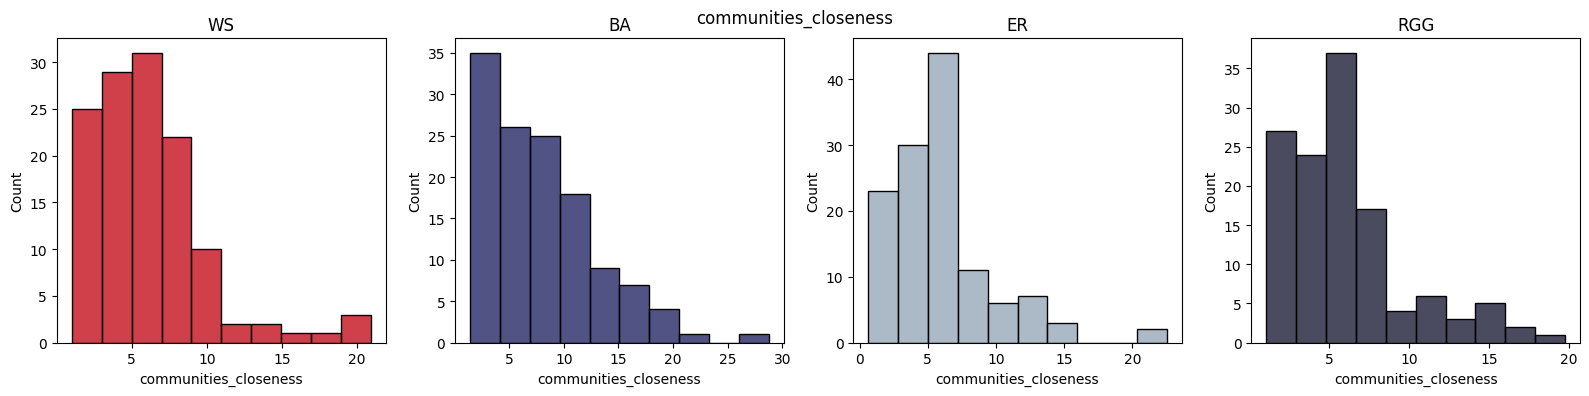

In [32]:
plot_component_distribution(calculated_comp_all, 'communities_closeness')

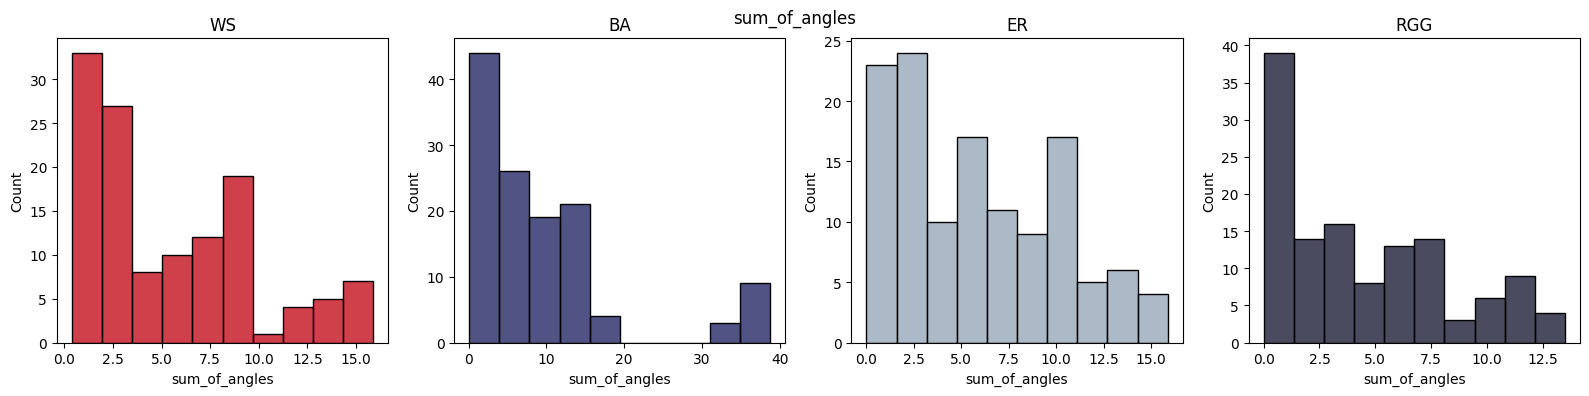

In [33]:
plot_component_distribution(calculated_comp_all, 'sum_of_angles')

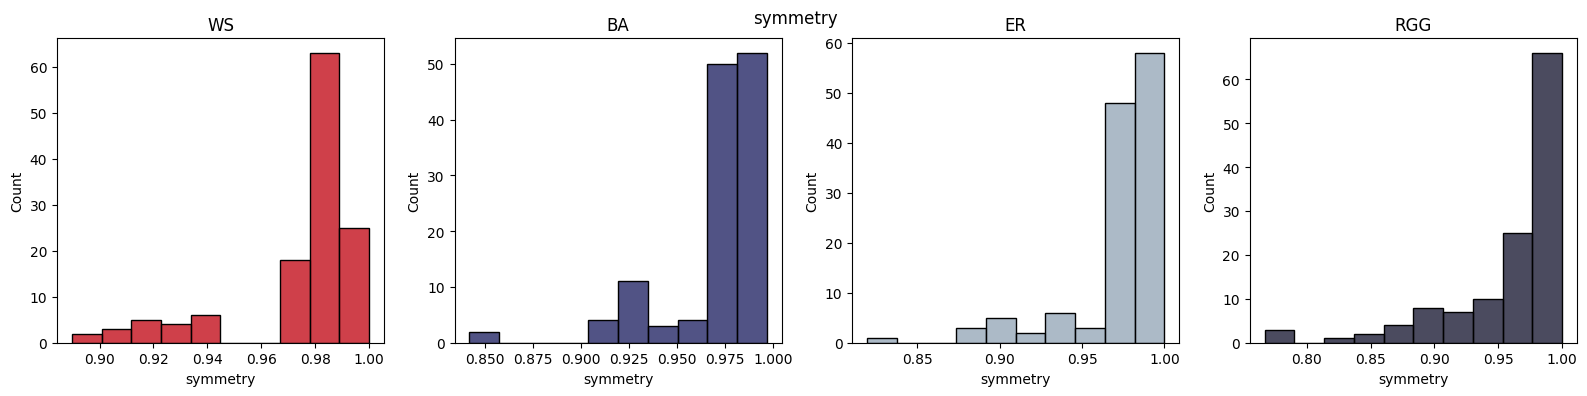

In [34]:
plot_component_distribution(calculated_comp_all, 'symmetry')

# Lasso with fixed alpha

In [51]:
# what to leave  -> conclusions from correlation analysis and vibes
# zostaje : node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
cols_to_be_droped = ['node_distribution','node_distribution_raw', 'distance_to_borderlines','distance_to_borderlines_raw', 'edge_length_sum_raw', 'edge_node_distance_contribution','edge_node_distance_contribution_raw', 'count_edge_crossings']

calculated_comp_WS = pd.read_csv('calculated_components\calculated_components_WS.csv')
calculated_comp_WS.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_BA = pd.read_csv('calculated_components\calculated_components_BA.csv')
calculated_comp_BA.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_ER = pd.read_csv('calculated_components\calculated_components_ER.csv')
calculated_comp_ER.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_RGG = pd.read_csv('calculated_components\calculated_components_RGG.csv')
calculated_comp_RGG.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_all = pd.read_csv('calculated_components\calculated_components_all.csv')
calculated_comp_all.drop(cols_to_be_droped, axis=1, inplace=True)


In [52]:
calculated_comp_all.head()

,score,node_distribution_unreversed,distance_to_borderlines_unreversed,edge_length_sum,edge_node_distance_contribution_unreversed,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,6,14.829592,24.0,2.152635,18.886689,0,4.595035,1.818732,0.923854,WS
1,2,9.414349,24.0,2.214927,11.224078,2,4.291184,1.857574,0.994254,WS
2,3,6.608169,24.0,1.848901,6.695052,5,2.975655,2.057628,0.994107,WS
3,4,7.465641,24.0,2.198073,7.175088,4,3.338765,1.824807,0.983865,WS
4,5,10.232899,24.0,3.359785,11.855137,2,4.698183,1.976676,0.983869,WS


In [6]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import joblib
# Load your dataset
# 
def Lasso_feature_importance(calculated_components, alpha=.4, save_scaler=False):
    calculated_components.drop('category', axis=1, inplace=True)
    y = calculated_components.iloc[:, 0]
    X = calculated_components.iloc[:, 1:]
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    if save_scaler:
        joblib.dump(scaler, r'scaler/scaler.pkl')

    # Fit the Lasso regression model
    lasso = Lasso(alpha=alpha, random_state=212)
    lasso.fit(X_scaled, y)

    # Get the feature importances
    feature_importances = pd.Series(lasso.coef_, index=X.columns)

    # Display the feature importances
    print("Feature importances using Lasso regression:")
    print(feature_importances)

    feature_importances_df = pd.DataFrame([feature_importances])
    return feature_importances_df
# feature_importances_df.to_csv('feature_importances.csv', index=False)


In [7]:
import warnings
warnings.filterwarnings("ignore")

fixed_alpha = 0.1

# calculated_comp_WS = pd.read_csv('lambdas\calculated_components_WS.csv')
print(' ====== WS ======')
lasso_ws = Lasso_feature_importance(calculated_comp_WS, fixed_alpha)

# calculated_comp_BA = pd.read_csv('lambdas\calculated_components_BA.csv')
print(' ====== BA ======')
lasso_ba = Lasso_feature_importance(calculated_comp_BA, fixed_alpha)

# calculated_comp_ER = pd.read_csv('lambdas\calculated_components_ER.csv')
print(' ====== ER ======')
lasso_er = Lasso_feature_importance(calculated_comp_ER, fixed_alpha)

# calculated_comp_RGG = pd.read_csv('lambdas\calculated_components_RGG.csv')
print(' ====== RGG ======')
lasso_rgg = Lasso_feature_importance(calculated_comp_RGG, fixed_alpha)

# calculated_comp_all = pd.read_csv('lambdas\calculated_components_all.csv')
print(' ====== ALL ======')
lasso_all = Lasso_feature_importance(calculated_comp_all, fixed_alpha)

 ====== WS ======
Feature importances using Lasso regression:
node_distribution_unreversed                  0.000000
distance_to_borderlines_unreversed           -0.061208
distance_to_borderlines_raw                  -0.000000
edge_length_sum                               0.000000
edge_node_distance_contribution_unreversed    0.469621
count_edge_crossings_raw                     -0.244101
communities_closeness                         0.000000
sum_of_angles                                -0.000000
symmetry                                     -0.505817
dtype: float64
 ====== BA ======
Feature importances using Lasso regression:
node_distribution_unreversed                  0.000000
distance_to_borderlines_unreversed           -0.065152
distance_to_borderlines_raw                  -0.000000
edge_length_sum                               0.000000
edge_node_distance_contribution_unreversed    0.461046
count_edge_crossings_raw                     -0.222512
communities_closeness               

In [8]:

lasso_ws['category'] = 'WS'
lasso_ba['category'] = 'BA'
lasso_er['category'] = 'ER'
lasso_rgg['category'] = 'RGG'
lasso_all['category'] = 'All'

all_cats_corrs = pd.concat([lasso_ws, lasso_ba, lasso_er, lasso_rgg, lasso_all], ignore_index=True)
all_cats_corrs.set_index('category', inplace=True)

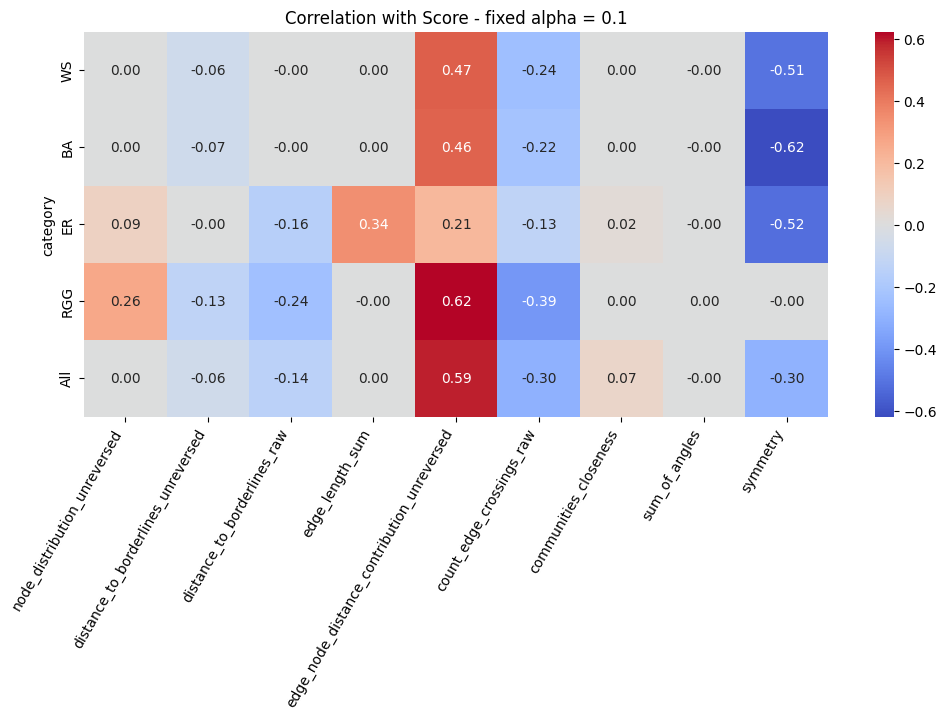

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))  # Adjust the figure size as needed
sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')
plt.title(f'Correlation with Score - fixed alpha = {fixed_alpha}')
plt.show()

In [23]:
lasso_ws.to_csv(r'lambdas/lasso_fixed_alpha_ws.csv', index = False)
lasso_ba.to_csv(r'lambdas/lasso_fixed_alpha_ba.csv', index = False)
lasso_er.to_csv(r'lambdas/lasso_fixed_alpha_er.csv', index = False)
lasso_rgg.to_csv(r'lambdas/lasso_fixed_alpha_rgg.csv', index = False)
lasso_all.to_csv(r'lambdas/lasso_fixed_alpha_all.csv', index = False)

# LASSO with proper training

In [15]:

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
import joblib

# calculated_components = pd.read_csv('lambdas\\calculated_components_WS.csv')

def Lasso_with_grid_search(calculated_components,  calculated_comp_all, category='BA', save_scaler=False):
    df = calculated_components.copy(deep=True)
    df.drop('category', axis=1, inplace=True)
    y = df.iloc[:, 0]
    X = df.iloc[:, 1:]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=212)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # if save_scaler:
    #     joblib.dump(scaler, fr'scaler/scaler_{category}.pkl')

    # Define the parameter grid for alpha
    param_grid = {'alpha': [i/100 for i in range(1, 100)]}

    # Initialize the Lasso model
    lasso = Lasso(random_state=212)
    grid_search = GridSearchCV(lasso, param_grid, cv=5)
    grid_search.fit(X_train_scaled, y_train)
    best_params = grid_search.best_params_
    print("Best parameters found: ", best_params)

    lasso_best = Lasso(**best_params)
    lasso_best.fit(X_train_scaled, y_train)

    y_pred = lasso_best.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error on test set: ", mse)

    feature_importances = pd.Series(lasso_best.coef_, index=X.columns)
    feature_importances_df = pd.DataFrame(feature_importances, columns=['Importance']).T


    #check mse on the whole dataset
    # if 'category' in all_df.columns:
    all_df = calculated_comp_all.copy(deep=True)
    all_df.drop('category', axis=1, inplace=True)
    all_y = all_df.iloc[:, 0]
    all_X = all_df.iloc[:, 1:]

    scaler = StandardScaler()
    all_X = scaler.fit_transform(all_X)
    if save_scaler:
        # joblib.dump(scaler, fr'scaler/scaler_{category}.pkl')
        joblib.dump(scaler, fr'scaler/scaler.pkl')

    y_pred = lasso_best.predict(all_X)
    mse_all = mean_squared_error(all_y, y_pred)
    print("MSE for whole dataset: ", mse_all)
    
    print("Feature importances using Lasso regression with tuned parameters:")
    print(feature_importances)

    return feature_importances_df


In [11]:
# what to leave  -> conclusions from correlation analysis and vibes
# zostaje : node_distribtuion, distance_to_brodelines, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
cols_to_be_droped = ['node_distribution','node_distribution_raw', 'distance_to_borderlines_unreversed','distance_to_borderlines_raw', 'edge_length_sum_raw', 'edge_node_distance_contribution','edge_node_distance_contribution_raw', 'count_edge_crossings']

calculated_comp_WS = pd.read_csv('calculated_components\calculated_components_WS.csv')
calculated_comp_WS.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_BA = pd.read_csv('calculated_components\calculated_components_BA.csv')
calculated_comp_BA.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_ER = pd.read_csv('calculated_components\calculated_components_ER.csv')
calculated_comp_ER.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_RGG = pd.read_csv('calculated_components\calculated_components_RGG.csv')
calculated_comp_RGG.drop(cols_to_be_droped, axis=1, inplace=True)

calculated_comp_all = pd.read_csv('calculated_components\calculated_components_all.csv')
calculated_comp_all.drop(cols_to_be_droped, axis=1, inplace=True)


In [17]:
print(' ====== WS ======')
features_ws = Lasso_with_grid_search(calculated_comp_WS, calculated_comp_all, 'WS')
print(' ====== BA ======')
features_ba = Lasso_with_grid_search(calculated_comp_BA,  calculated_comp_all,'BA')
print(' ====== ER ======')
features_er = Lasso_with_grid_search(calculated_comp_ER, calculated_comp_all, 'ER')
print(' ====== RGG ======')
features_rgg = Lasso_with_grid_search(calculated_comp_RGG, calculated_comp_all, 'RGG')
print(' ====== All ======')
features_all = Lasso_with_grid_search(calculated_comp_all,  calculated_comp_all,'All', save_scaler=True)

 ====== WS ======
Best parameters found:  {'alpha': 0.04}
Mean Squared Error on test set:  2.211440624961763
MSE for whole dataset:  2.2758807623492077
Feature importances using Lasso regression with tuned parameters:
node_distribution_unreversed                 -0.000000
distance_to_borderlines                       0.244646
edge_length_sum                               0.000000
edge_node_distance_contribution_unreversed    0.393184
count_edge_crossings_raw                     -0.318381
communities_closeness                         0.077324
sum_of_angles                                -0.000000
symmetry                                     -0.443206
dtype: float64
 ====== BA ======
Best parameters found:  {'alpha': 0.08}
Mean Squared Error on test set:  2.394358866300321
MSE for whole dataset:  2.2762063330626776
Feature importances using Lasso regression with tuned parameters:
node_distribution_unreversed                 -0.000000
distance_to_borderlines                       0.000000

In [18]:

features_ws['category'] = 'WS'
features_ba['category'] = 'BA'
features_er['category'] = 'ER'
features_rgg['category'] = 'RGG'
features_all['category'] = 'All'

all_cats_corrs = pd.concat([features_ws, features_ba, features_er, features_rgg, features_all], ignore_index=True)
all_cats_corrs.set_index('category', inplace=True)

In [19]:

#! saving to file

features_ws.to_csv(r'lambdas\ws_lasso.csv', index=False)
features_er.to_csv(r'lambdas\er_lasso.csv', index=False)
features_ba.to_csv(r'lambdas\ba_lasso.csv', index=False)
features_rgg.to_csv(r'lambdas\rgg_lasso.csv', index=False)
features_all.to_csv(r'lambdas\all_lasso.csv', index=False)

In [2]:
#tun if environement reseter
import pandas as pd

features_ws = pd.read_csv(r'lambdas\ws_lasso.csv')
features_er=pd.read_csv(r'lambdas\er_lasso.csv')
features_ba=pd.read_csv(r'lambdas\ba_lasso.csv')
features_rgg=pd.read_csv(r'lambdas\rgg_lasso.csv')
features_all=pd.read_csv(r'lambdas\all_lasso.csv')

features_ws['category'] = 'WS'
features_ba['category'] = 'BA'
features_er['category'] = 'ER'
features_rgg['category'] = 'RGG'
features_all['category'] = 'All'

all_cats_corrs = pd.concat([features_ws, features_ba, features_er, features_rgg, features_all], ignore_index=True)
all_cats_corrs.set_index('category', inplace=True)

In [21]:
all_cats_corrs

,node_distribution_unreversed,distance_to_borderlines,edge_length_sum,edge_node_distance_contribution_unreversed,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry
category,,,,,,,,
WS,-0.0,0.244646,0.000000,0.393184,-0.318381,0.077324,-0.0,-0.443206
BA,-0.0,0.000000,0.000000,0.371870,-0.172124,0.000000,0.0,-0.691498
ER,0.0,-0.000000,0.313560,0.210834,-0.275568,0.131063,-0.0,-0.387338
RGG,0.0,-0.000000,-0.000000,0.569580,-0.435840,0.000000,0.0,-0.000000
All,-0.0,-0.142566,0.068056,0.667807,-0.502632,0.066258,-0.0,-0.325194


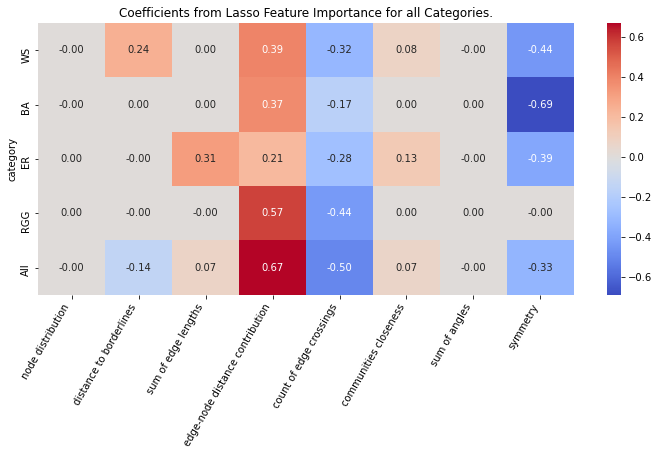

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=(14, 5)) # Adjust the figure size as needed 
# sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True) 
# plt.xticks(rotation=60, ha='right') 
# plt.title('Feature Importance Results from Lasso') 
# plt.show()

plt.figure(figsize=(12, 5))  # Adjust the figure size as needed
sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

# Set custom x-axis labels
custom_labels = ['node distribution', 'distance to borderlines', 'sum of edge lengths', 'edge-node distance contribution', 
                 'count of edge crossings', 'communities closeness', 'sum of angles', 'symmetry']  # Replace with your desired labels
plt.xticks(ticks=plt.xticks()[0], labels=custom_labels, rotation=60, ha='right')

plt.title('Coefficients from Lasso Feature Importance for all Categories.')
plt.show()

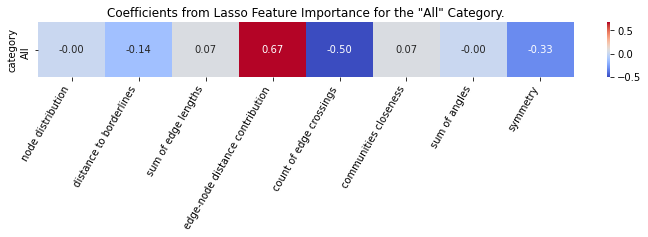

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for the "All" category
# Replace 'All' with the actual column/row name or condition that corresponds to the "All" category
all_category_corrs = all_cats_corrs.loc[['All'], :]  # If "All" is a row
# all_category_corrs = all_cats_corrs.loc[:, ['All']]  # If "All" is a column

plt.figure(figsize=(12, 1))  # Adjust the figure size as needed
sns.heatmap(all_category_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

# Set custom x-axis labels
custom_labels = ['node distribution', 'distance to borderlines', 'sum of edge lengths', 'edge-node distance contribution', 
                 'count of edge crossings', 'communities closeness', 'sum of angles', 'symmetry']  # Replace with your desired labels
plt.xticks(ticks=plt.xticks()[0], labels=custom_labels, rotation=60, ha='right')

plt.title('Coefficients from Lasso Feature Importance for the "All" Category.')
plt.show()

In [16]:
# decyzja : mysle ze wylane i brac po prostu all

In [ ]:
# node_distribtuion, edge_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw

# Looking into whats going on in scalers

In [32]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_ws.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [2.03069831e+02 1.37480677e+04 4.09256417e+00 7.58018961e+02
 5.09000000e+00 6.26209107e+00 5.56574532e+00 9.74360215e-01]
Variance: [6.00763780e+04 1.85447052e+10 1.21905287e+01 3.99238781e+06
 2.71219000e+01 1.42027299e+01 1.62867739e+01 5.30325486e-04]
Scale: [2.45104831e+02 1.36178945e+05 3.49149377e+00 1.99809605e+03
 5.20786905e+00 3.76865094e+00 4.03568754e+00 2.30287969e-02]


In [33]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_ba.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [625.08709547  67.04643      4.11466006 804.74303453   8.24
   7.77316332   8.97477597   0.97206079]
Variance: [9.49613800e+05 1.97180299e+03 6.46563488e+00 1.98253797e+06
 1.17082400e+02 2.67988669e+01 8.46463320e+01 7.45088386e-04]
Scale: [9.74481298e+02 4.44049884e+01 2.54276127e+00 1.40802627e+03
 1.08204621e+01 5.17676220e+00 9.20034413e+00 2.72963072e-02]


In [34]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_er.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [4.00434499e+02 1.37010397e+03 4.29316339e+00 3.79161377e+02
 5.08000000e+00 5.73322761e+00 5.85601931e+00 9.73115935e-01]
Variance: [6.05977227e+05 1.70120995e+08 1.63958736e+01 2.27964604e+05
 3.39736000e+01 1.35298904e+01 1.85877498e+01 7.56760820e-04]
Scale: [7.78445391e+02 1.30430439e+04 4.04918184e+00 4.77456389e+02
 5.82868767e+00 3.67829994e+00 4.31135127e+00 2.75092861e-02]


In [35]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_rgg.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [2.72391499e+02 2.50216557e+04 4.25367600e+00 1.91483629e+04
 3.73000000e+00 6.20971077e+00 4.57866189e+00 9.58400300e-01]
Variance: [1.30710610e+05 6.06395879e+10 1.59994001e+01 3.50218106e+10
 1.88571000e+01 1.49347671e+01 1.43200666e+01 2.11685563e-03]
Scale: [3.61539223e+02 2.46251067e+05 3.99992501e+00 1.87141151e+05
 4.34247625e+00 3.86455264e+00 3.78418639e+00 4.60092994e-02]


In [36]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_all.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [3.28347709e+02 5.72381986e+04 4.37055453e+00 5.33440112e+03
 5.66997519e+00 6.59261712e+00 6.41176897e+00 9.67596939e-01]
Variance: [3.08020865e+05 1.04602848e+12 1.38296668e+01 8.75571219e+09
 5.50250787e+01 1.82524560e+01 4.15660028e+01 1.20018043e-03]
Scale: [5.54996275e+02 1.02275534e+06 3.71882600e+00 9.35719626e+04
 7.41788910e+00 4.27228931e+00 6.44717014e+00 3.46436203e-02]
